<a href="https://colab.research.google.com/github/m1deey/Late_delivery-/blob/main/Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
df=pd.read_csv("olist_late_delivery_dataset.csv")
df.head()

,order_id,customer_state,seller_state,product_category,product_weight_g,product_length_cm,product_height_cm,product_width_cm,purchase_month,purchase_dow,n_items,total_price,total_freight,avg_installments,is_late
0,36e694cf4cbc2a4803200c35e84abdc4,SP,SP,computers_accessories,100.0,16.0,3.0,13.0,2.0,1.0,1.0,14.99,7.78,1.0,0.0
1,7433cbcc783205509d66a5260da5b574,MG,PR,furniture_decor,2500.0,40.0,10.0,30.0,1.0,1.0,1.0,99.90,22.57,1.0,0.0
2,83d8f70418eefd96f37b483dff430305,SP,MG,air_conditioning,2000.0,20.0,10.0,20.0,9.0,6.0,1.0,99.00,18.31,1.0,0.0
3,6c949e670b5d33dc8fb8ad25b6da4860,RS,PR,health_beauty,433.0,19.0,14.0,15.0,4.0,0.0,1.0,84.00,18.47,10.0,0.0
4,17825f24877a9289214c301ae0c9424b,SP,SP,bed_bath_table,1383.0,50.0,10.0,40.0,5.0,4.0,2.0,179.80,24.26,1.0,1.0


In [25]:
df.shape
df=df.drop(columns="order_id",axis=1)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 42885 entries, 0 to 42884
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_state      42885 non-null  object 
 1   seller_state        42885 non-null  object 
 2   product_category    42885 non-null  object 
 3   product_weight_g    42885 non-null  float64
 4   purchase_month      42885 non-null  float64
 5   purchase_dow        42885 non-null  float64
 6   n_items             42885 non-null  float64
 7   total_price         42885 non-null  float64
 8   total_freight       42885 non-null  float64
 9   avg_installments    42885 non-null  float64
 10  is_late             42885 non-null  float64
 11  product_volume_cm3  42885 non-null  float64
 12  freight_ratio       42885 non-null  float64
 13  same_state          42885 non-null  int64  
dtypes: float64(10), int64(1), object(3)
memory usage: 4.9+ MB


In [10]:
df.describe()

,product_weight_g,product_length_cm,product_height_cm,product_width_cm,purchase_month,purchase_dow,n_items,total_price,total_freight,avg_installments,is_late
count,42885.000000,42885.000000,42885.000000,42885.000000,42885.000000,42885.000000,42885.000000,42885.000000,42885.000000,42885.000000,42885.000000
mean,2083.640061,30.170922,16.315332,23.057946,6.033392,2.917244,1.147931,139.504277,22.909965,2.966791,0.078139
std,3726.180860,16.225712,13.276348,11.797315,3.223907,1.899927,0.618473,248.716249,22.748113,2.754982,0.268394
min,0.000000,7.000000,2.000000,8.000000,1.000000,0.000000,1.000000,0.850000,0.000000,1.000000,0.000000
25%,300.000000,18.000000,8.000000,15.000000,3.000000,1.000000,1.000000,45.000000,13.670000,1.000000,0.000000
50%,694.000000,25.000000,13.000000,20.000000,6.000000,3.000000,1.000000,84.990000,17.080000,2.000000,0.000000
75%,1800.000000,38.000000,20.000000,30.000000,8.000000,5.000000,1.000000,149.900000,23.920000,4.000000,0.000000
max,40425.000000,105.000000,105.000000,118.000000,12.000000,6.000000,24.000000,13440.000000,838.600000,24.000000,1.000000


In [11]:
df["customer_state"].value_counts()

,count
customer_state,
SP,18101
RJ,5518
MG,4991
RS,2345
PR,2156
SC,1582
BA,1429
ES,899
DF,885


In [13]:
df["product_category"].value_counts()

,count
product_category,
bed_bath_table,4235
health_beauty,3774
sports_leisure,3349
computers_accessories,2919
furniture_decor,2834
...,...
la_cuisine,7
arts_and_craftmanship,7
cds_dvds_musicals,6


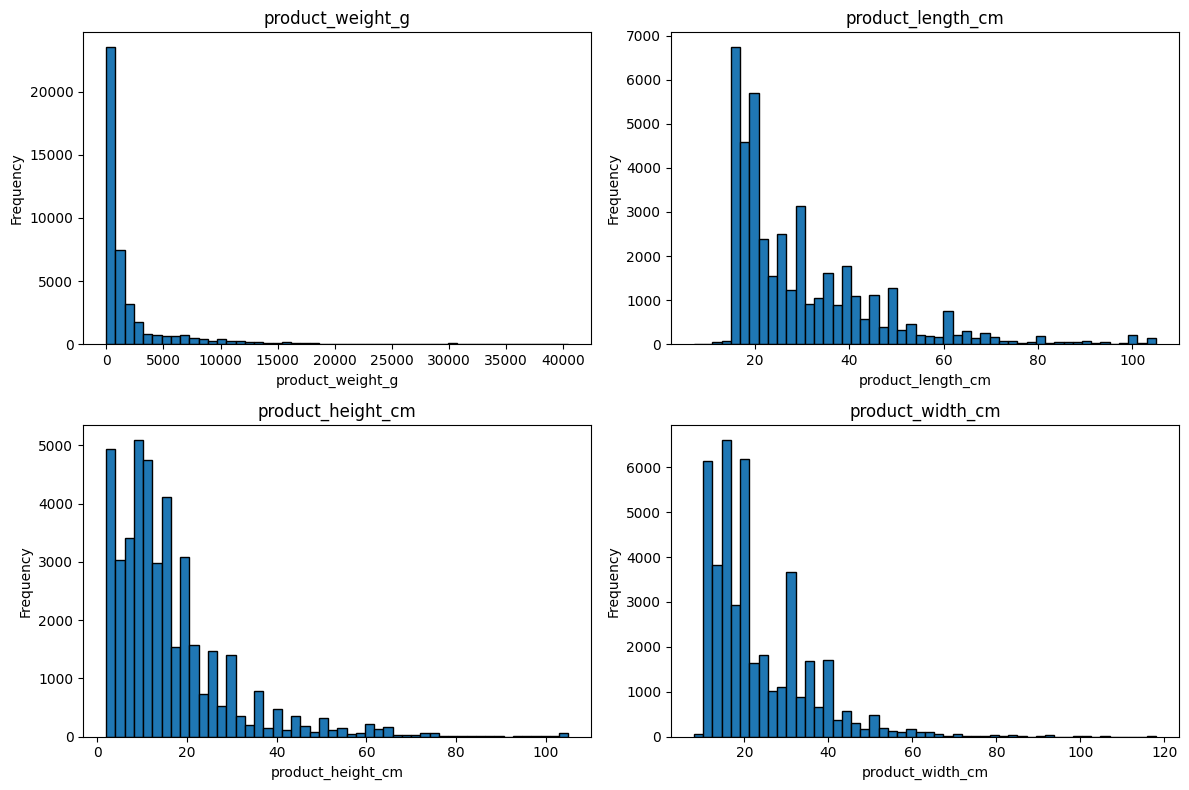

In [14]:
import matplotlib.pyplot as plt

cols = ['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(cols):
    axes[i].hist(df[col], bins=50, edgecolor='black')
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [15]:
df['product_volume_cm3'] = df['product_length_cm'] * df['product_height_cm'] * df['product_width_cm']
df = df.drop(columns=['product_length_cm', 'product_height_cm', 'product_width_cm'])
df['freight_ratio'] = df['total_freight'] / df['total_price']

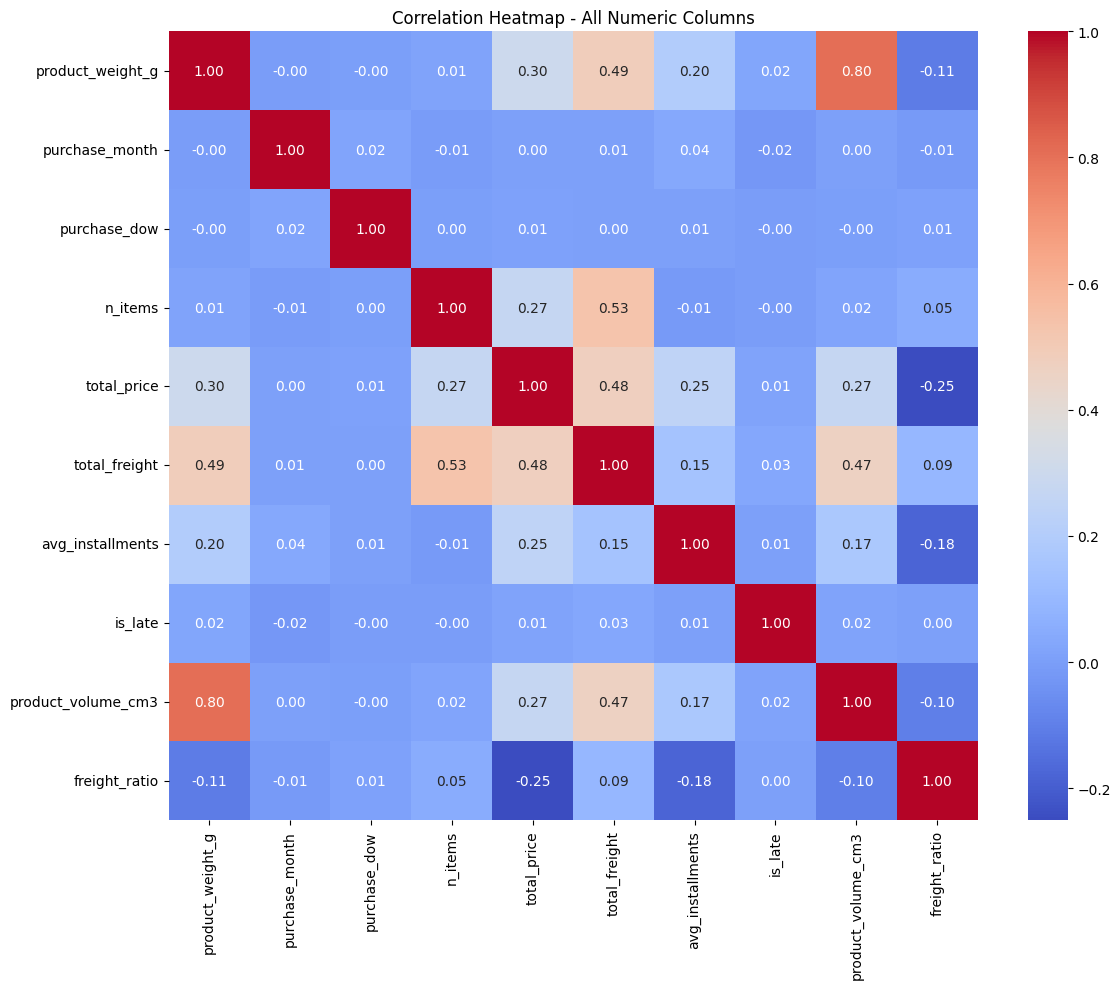

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_df = df.select_dtypes(include='number')

plt.figure(figsize=(12, 10))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap - All Numeric Columns')
plt.tight_layout()
plt.show()

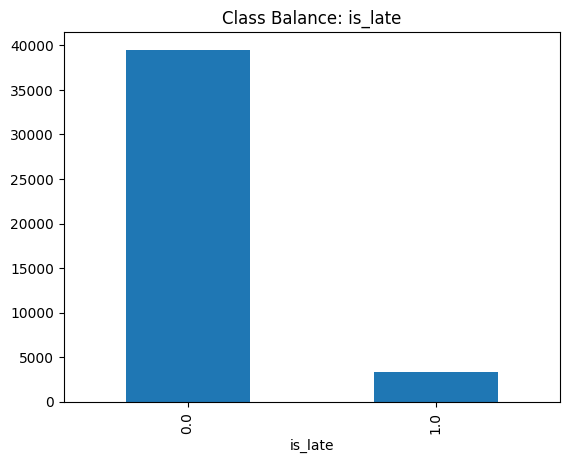

In [17]:
df['is_late'].value_counts().plot(kind='bar')
plt.title('Class Balance: is_late')
plt.show()

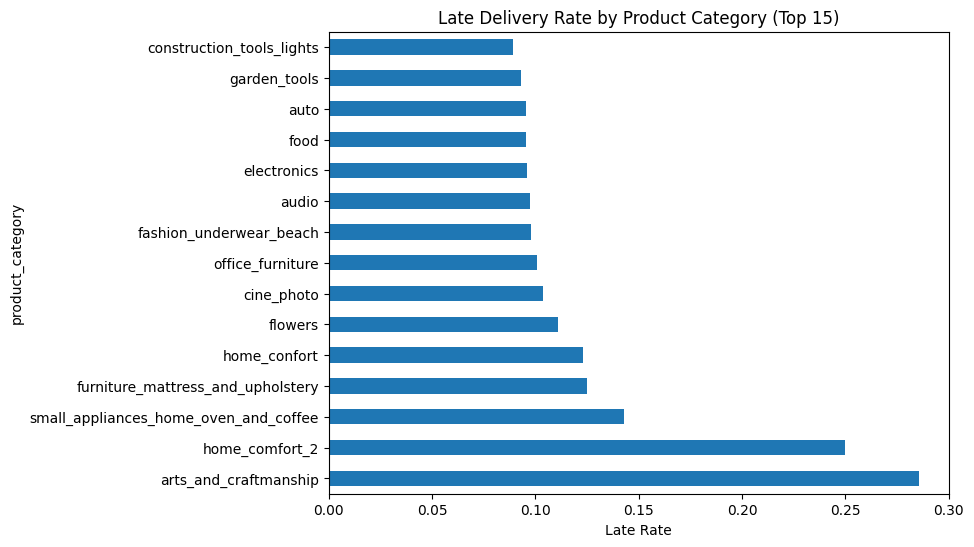

In [18]:
late_by_cat = df.groupby('product_category')['is_late'].mean().sort_values(ascending=False).head(15)
late_by_cat.plot(kind='barh', figsize=(8,6))
plt.title('Late Delivery Rate by Product Category (Top 15)')
plt.xlabel('Late Rate')
plt.show()

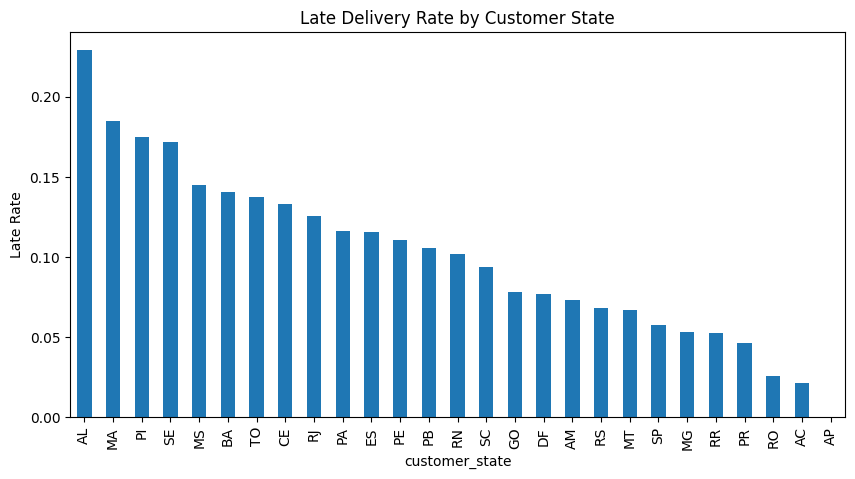

In [19]:
late_by_state = df.groupby('customer_state')['is_late'].mean().sort_values(ascending=False)
late_by_state.plot(kind='bar', figsize=(10,5))
plt.title('Late Delivery Rate by Customer State')
plt.ylabel('Late Rate')
plt.show()

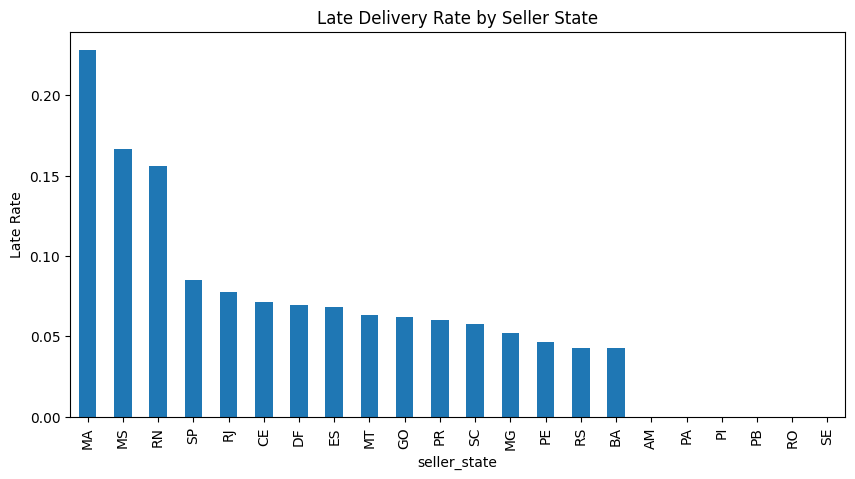

In [20]:
late_by_seller = df.groupby('seller_state')['is_late'].mean().sort_values(ascending=False)
late_by_seller.plot(kind='bar', figsize=(10,5))
plt.title('Late Delivery Rate by Seller State')
plt.ylabel('Late Rate')
plt.show()

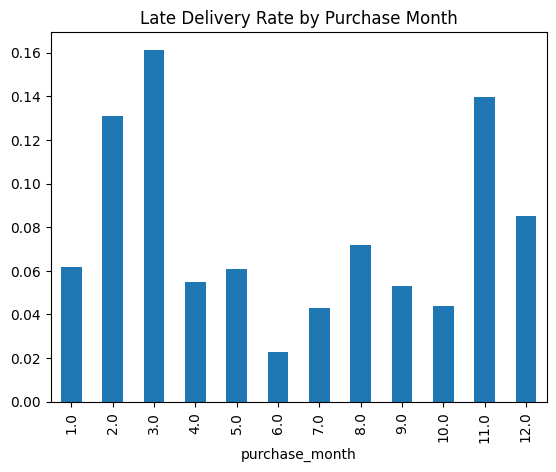

In [21]:
df.groupby('purchase_month')['is_late'].mean().plot(kind='bar')
plt.title('Late Delivery Rate by Purchase Month')
plt.show()

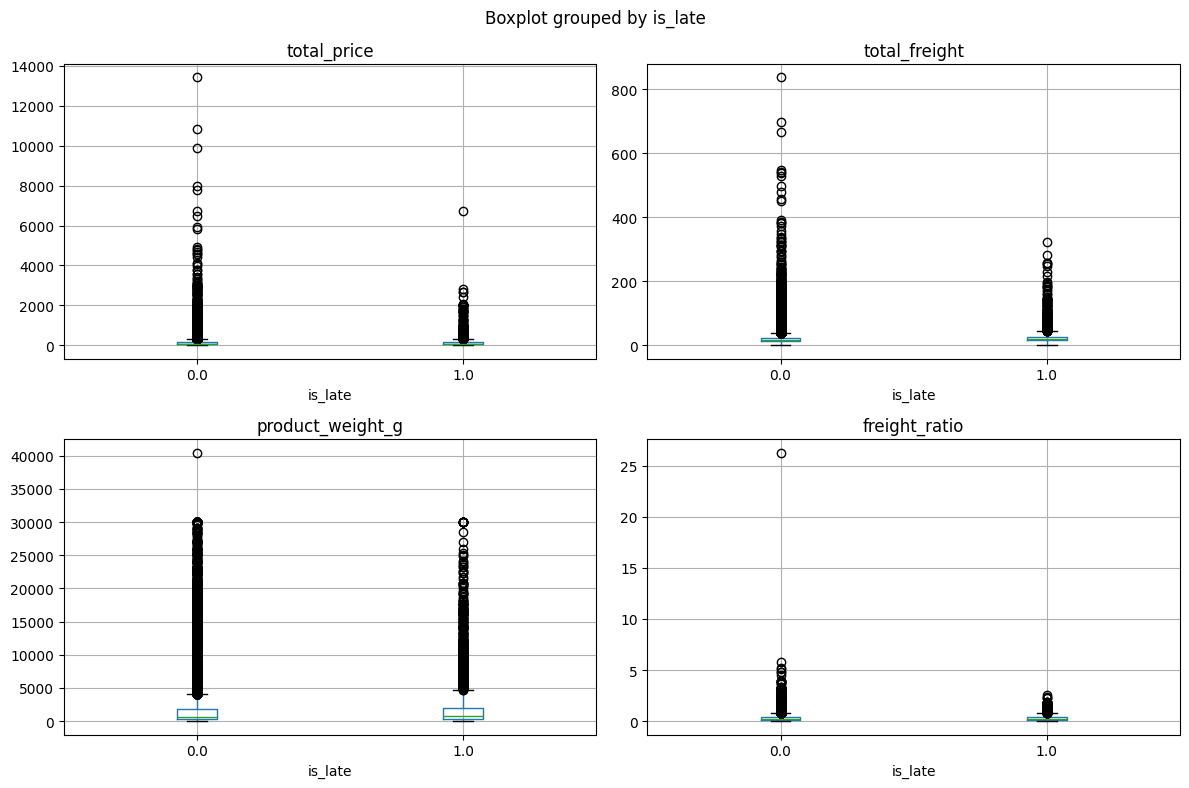

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(12,8))
for i, col in enumerate(['total_price', 'total_freight', 'product_weight_g', 'freight_ratio']):
    df.boxplot(column=col, by='is_late', ax=axes[i//2][i%2])
plt.tight_layout()
plt.show()

In [23]:
df['same_state'] = (df['customer_state'] == df['seller_state']).astype(int)
df['same_state'].value_counts()

,count
same_state,
0,27325
1,15560


In [24]:
df.groupby('same_state')['is_late'].mean()

,is_late
same_state,
0,0.089039
1,0.058997


In [27]:
from sklearn.model_selection import train_test_split

X = df.drop(columns="is_late",axis=1)
y = df['is_late']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [28]:
categorical_cols = ['customer_state', 'seller_state', 'product_category']
numeric_cols = [c for c in X.columns if c not in categorical_cols]
print(numeric_cols)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

['product_weight_g', 'purchase_month', 'purchase_dow', 'n_items', 'total_price', 'total_freight', 'avg_installments', 'product_volume_cm3', 'freight_ratio', 'same_state']


In [29]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

In [35]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10],
    'classifier__penalty': ['l1', 'l2'],
    'classifier__solver': ['liblinear']
}

grid_search = GridSearchCV(
    pipeline, param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print("Best CV F1:", grid_search.best_score_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best params: {'classifier__C': 0.1, 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}
Best CV F1: 0.19243367358635807


Accuracy: 0.6630523493062842
Precision: 0.12550607287449392
Recall: 0.5552238805970149
F1: 0.20473307649972483

               precision    recall  f1-score   support

         0.0       0.95      0.67      0.79      7907
         1.0       0.13      0.56      0.20       670

    accuracy                           0.66      8577
   macro avg       0.54      0.61      0.50      8577
weighted avg       0.88      0.66      0.74      8577



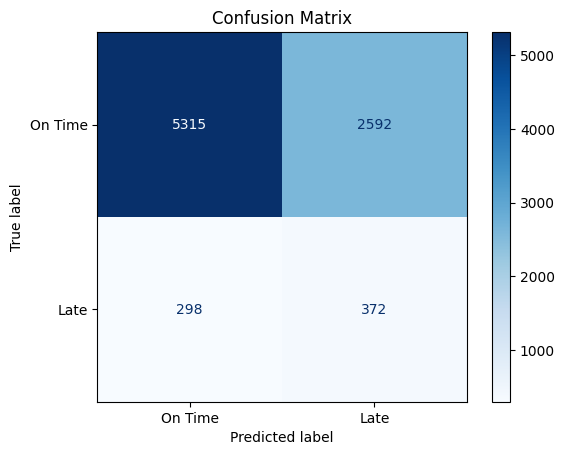

In [36]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['On Time', 'Late'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

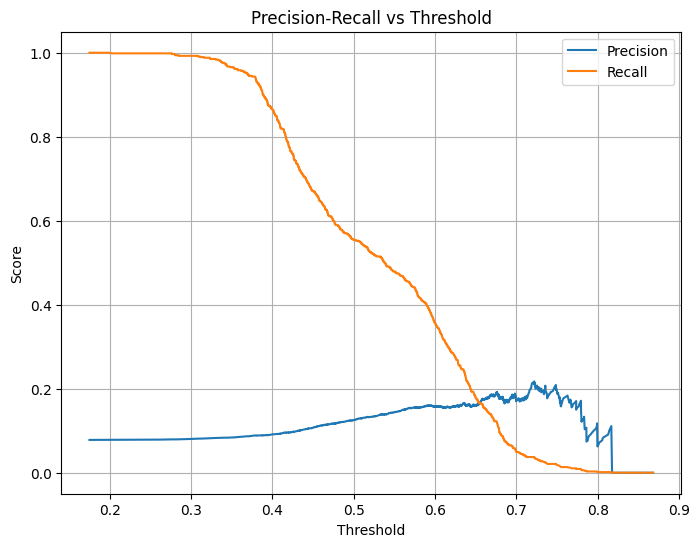

In [37]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

y_proba = best_model.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(8,6))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall vs Threshold')
plt.legend()
plt.grid(True)
plt.show()

From the graph the model doesn't separate the data well

In [38]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(class_weight='balanced', random_state=42))
])

rf_param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [10, 20, None],
    'classifier__min_samples_leaf': [1, 5, 10]
}

rf_grid_search = GridSearchCV(
    rf_pipeline, rf_param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=1
)
rf_grid_search.fit(X_train, y_train)

print("Best params:", rf_grid_search.best_params_)
print("Best CV F1:", rf_grid_search.best_score_)

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best params: {'classifier__max_depth': 20, 'classifier__min_samples_leaf': 5, 'classifier__n_estimators': 200}
Best CV F1: 0.27805917448995343


Accuracy: 0.8558936691150753
Precision: 0.23402255639097744
Recall: 0.3716417910447761
F1: 0.28719723183391005

               precision    recall  f1-score   support

         0.0       0.94      0.90      0.92      7907
         1.0       0.23      0.37      0.29       670

    accuracy                           0.86      8577
   macro avg       0.59      0.63      0.60      8577
weighted avg       0.89      0.86      0.87      8577



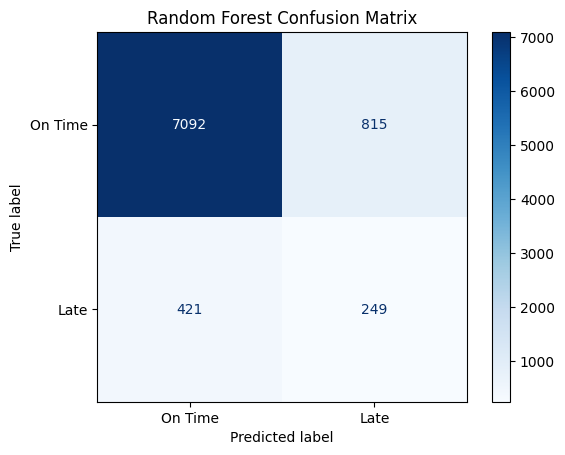

In [39]:
best_rf = rf_grid_search.best_estimator_
y_pred_rf = best_rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1:", f1_score(y_test, y_pred_rf))
print("\n", classification_report(y_test, y_pred_rf))

cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['On Time', 'Late'])
disp_rf.plot(cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.show()

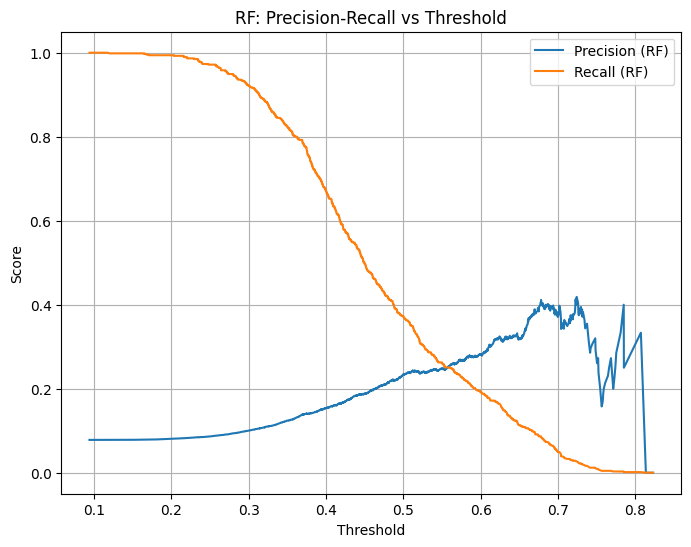

In [40]:
y_proba_rf = best_rf.predict_proba(X_test)[:, 1]
precisions_rf, recalls_rf, thresholds_rf = precision_recall_curve(y_test, y_proba_rf)

plt.figure(figsize=(8,6))
plt.plot(thresholds_rf, precisions_rf[:-1], label='Precision (RF)')
plt.plot(thresholds_rf, recalls_rf[:-1], label='Recall (RF)')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('RF: Precision-Recall vs Threshold')
plt.legend()
plt.grid(True)
plt.show()

In [41]:
from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight:", scale_pos_weight)

xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss',
        random_state=42
    ))
])

xgb_param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [3, 5, 7],
    'classifier__learning_rate': [0.01, 0.1, 0.2]
}

xgb_grid_search = GridSearchCV(
    xgb_pipeline, xgb_param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=1
)
xgb_grid_search.fit(X_train, y_train)

print("Best params:", xgb_grid_search.best_params_)
print("Best CV F1:", xgb_grid_search.best_score_)

scale_pos_weight: 11.796717642670645
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best params: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 7, 'classifier__n_estimators': 200}
Best CV F1: 0.2705055630430049


Accuracy: 0.807508452838988
Precision: 0.19170333123821495
Recall: 0.4552238805970149
F1: 0.2697921273772667

               precision    recall  f1-score   support

         0.0       0.95      0.84      0.89      7907
         1.0       0.19      0.46      0.27       670

    accuracy                           0.81      8577
   macro avg       0.57      0.65      0.58      8577
weighted avg       0.89      0.81      0.84      8577



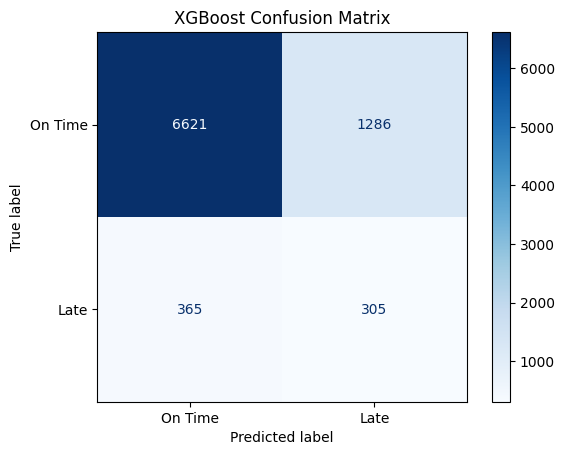

In [42]:
best_xgb = xgb_grid_search.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("F1:", f1_score(y_test, y_pred_xgb))
print("\n", classification_report(y_test, y_pred_xgb))

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=['On Time', 'Late'])
disp_xgb.plot(cmap='Blues')
plt.title('XGBoost Confusion Matrix')
plt.show()

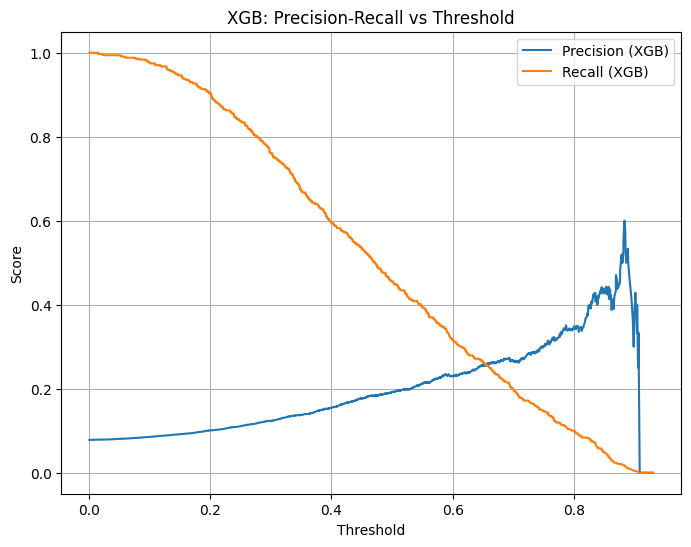

In [43]:
y_proba_xgb = best_xgb.predict_proba(X_test)[:, 1]
precisions_xgb, recalls_xgb, thresholds_xgb = precision_recall_curve(y_test, y_proba_xgb)

plt.figure(figsize=(8,6))
plt.plot(thresholds_xgb, precisions_xgb[:-1], label='Precision (XGB)')
plt.plot(thresholds_xgb, recalls_xgb[:-1], label='Recall (XGB)')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('XGB: Precision-Recall vs Threshold')
plt.legend()
plt.grid(True)
plt.show()

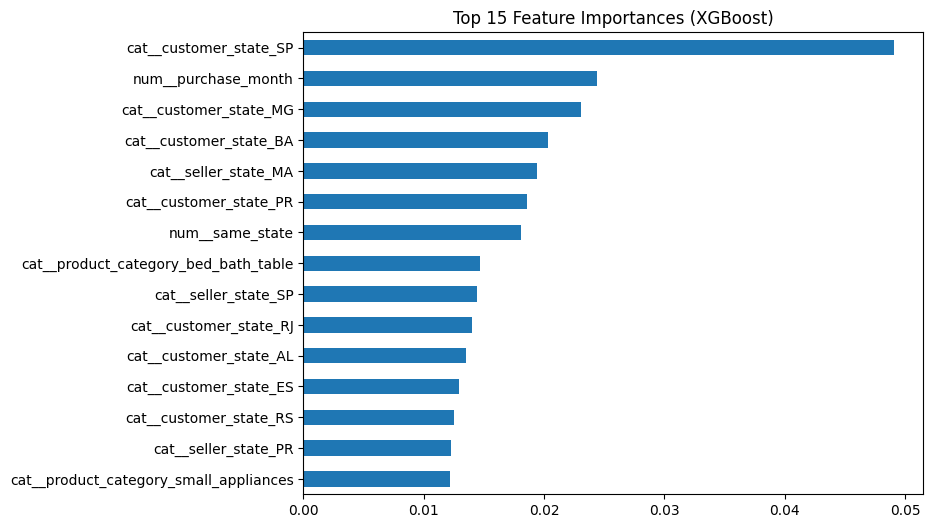

In [45]:
importances = best_xgb.named_steps['classifier'].feature_importances_
feature_names = best_xgb.named_steps['preprocessor'].get_feature_names_out()

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(15)
feat_imp.plot(kind='barh', figsize=(8,6))
plt.title('Top 15 Feature Importances (XGBoost)')
plt.gca().invert_yaxis()
plt.show()